This part would be extending the backpropagation from `Part 1` PyTorch functions  

Lets copy some of the important stuff from the `Part 1`

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self._backward = lambda: None
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        # This will help in creating the linked-list
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # this is for doing something like a + 1
        # basically converts anything which is not of type `Value` to `Value`
        out = Value(self.data + other.data, (self, other), '+') 
 
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad 
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*') 
        
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad 
        out._backward = _backward
        
        return out
        
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float for now"
        out = Value(self.data**other, (self,), f'**{other}') # self.data^(other)

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad # d(x^n)/dx = n.x^(n-1)
        out._backward = _backward

        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 

        def _backward(): 
            self.grad += (1 - t**2) * out.grad # modified the contribution, to avoid over-write
            # or 
            # self.grad = (1 - out.value**2) * out.grad 
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad # out.data as d(e^x)/dx = e^x
        out._backward = _backward

        return out

    ## For the following methods, before backward, we haven't called backward() or calculated the .grad()
    # REASON: these methods will be calling the other methods like __add__() and __muk__() while returning
    def __rmul__(self, other): # other * self 
        return self * other 
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __truediv__(self, other): # self / other
        # a / b = a * b^(-1)
        # this is more generic and will be helpful later.
        return self * other**-1
    
    def __neg__(self): # self
        return self * - 1
    
    def __sub__(self, other): # self - other
        return self + (-other)


    # This will be called once 
    def backward(self):
        visited = set()
        topo = [] # topologically sorted list
        # related to automatic backpropagation, using topological sort
        def build_topo(node):
            if node not in visited:
                # first we have to add the node into the set 
                visited.add(node)
                # for non-leaf nodes, traverse their children first
                for child in node._prev:
                    build_topo(child)
                # for leaf nodes
                topo.append(node)
        # now call this sort from the last node, it will traverse the whole list using the ._prev variable.
        build_topo(self)

        # now for the calculation of backpropagation we have to traverse the list in a reversed way. 
        self.grad = 1.0 # value of gradient for the last node 
        for node in reversed(topo):
            node._backward()


In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

Intro to `Pytorch`

In [4]:
import torch

In [5]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


We are casting the `tensors` to double `64bit` precision point to align it with the default of `python`.  
Pytorch normally uses `32bit` precision point.  
`.requires_grad` because, by default pytorch believes it to be `false`.  
For example: the leaf nodes are not supposed ot have `gradients`.

In [6]:
o.data.item()

0.7071066904050358

In [7]:
o.data

tensor([0.7071], dtype=torch.float64)

$\therefore$ without the `.item()`, `Pytorch` returns a `tensor`.  
And using that function we get the value after the dimension is stripped.  
Also, here `o.item()` and `o.data.item()` will produce the same result in `Pytorch`

Bringing the picture of the neuron for better reference in later sections  
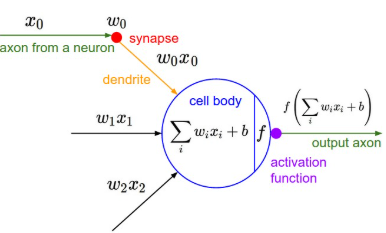

In [ ]:
import random

class Neuron:
  
  # here `nin` is the no. of inputs to the cell body
  def __init__(self, nin):
    # it creates a random weight between -1 and 1 for every input. i.e. w_i for every x_i
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # and we need a single bias. 
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # this is the raw activation
    # and then we need to pass that through non-linearity
    out = act.tanh()
    return out
  
x = [2.0, 3.0]
n = Neuron(2) # here 2 is the `nin` which means the dimension, as in the no. of arguments it takes. 
n(x)

Value(data=0.7221992536184845)

### NOTES on the `zip(self.w, x)`.  
<!-- It pairs elements from the two iterables position by position.

If:
```python
self.w = [w1, w2, w3]
x = [x1, x2, x3]
```

then:

```python
zip(self.w, x)
```

behaves like:

$
\boxed{(w1, x1), (w2, x2), (w3, x3)}
$


So in code like:

```python
sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
```

It does the computation like:  
$
w_1x_1 + w_2x_2 + \cdots + b
$

This is the basic computation inside a neuron.  

Important detail:
- `zip` stops at the shortest iterable
- so if lengths differ, extra elements are ignored

Example:
```python
self.w = [1, 2, 3]
x = [10, 20, 30]

list(zip(self.w, x))
# [(1, 10), (2, 20), (3, 30)]
``` -->


### NOTES on the Python `sum()`.

<!-- ```python
sum(iterable, start=0)
```

Arguments:

- `iterable`
  - the values you want to add
  - example:
    ```python
    [1, 2, 3]
    ```

- `start`
  - optional initial value
  - default is `0`
  - sum begins from this value

Examples:

```python
sum([1, 2, 3])
# 6
```

```python
sum([1, 2, 3], 10)
# 16
```

In `micrograd`, you often see:

```python
sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
```

Here:
- `iterable` = generator of `wi * xi`
- `start` = `self.b`

So it computes:

$
b + w_1x_1 + w_2x_2 + \cdots
$

That is why `self.b` is passed as the second argument. -->

uncomment the following explanations from this markdown cell, if needed.  

## Designing the Layers on a Neural Network
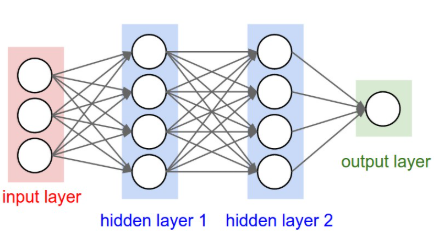   

Fig1: A simple MLP  
- takes 3 input, i.e. input is 3 dimensional  
- 2 middle layers of 4 dimensions (4 neurons each)
- output dimension is 1 (i.e. 1 output neuron)  

First we would be designing a single layer of neurons

In [ ]:
import random

class Neuron:
  
  # here `nin` is the no. of inputs to the cell body
  def __init__(self, nin):
    # it creates a random weight between -1 and 1 for every input. i.e. w_i for every x_i
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # and we need a single bias. 
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # this is the raw activation
    # and then we need to pass that through non-linearity
    out = act.tanh()
    return out
  
# A layer is just a list of Neurons
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs
  
  
x = [2.0, 3.0]
n = Layer(2, 3) # Here 3, or `nout` is the no. of neurons in a single layer. 
n(x) 

[Value(data=0.8913454498411982),
 Value(data=0.9921216644411346),
 Value(data=-0.994724298210844)]

Design for an MLP (Multi-Layer Perceptron)  

In [24]:
import random

class Neuron:
  
  # here `nin` is the no. of inputs to the cell body
  def __init__(self, nin):
    # it creates a random weight between -1 and 1 for every input. i.e. w_i for every x_i
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1)) # a single bias. 
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # y = m1x1 +m2x2 + .... + b
    out = act.tanh()
    return out
  
# A layer is just a list of Neurons
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs
    # return outs[0] if len(outs) == 1 else outs
  
  # def parameters(self):
  #   return [p for neuron in self.neurons for p in neuron.parameters()]
  
class MLP:
  
  def __init__(self, nin, nouts):
    # sz is the size of all the layers in the MLP (no. of neurons in each layer)
    sz = [nin] + nouts # that concats the list and creates `sz = [3, 4, 4, 1]`. explanation below. 
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) 
    return x

  
x = [2.0, 3.0, -1.0] # dimension of input 
"""
n = Neuron(3) # here 3 is the `nin`, or no. of inputs. That means the dimension. 
# doesn't matter the size of `x`, the input size of the Neuron is all that matters. If its smaller than the 
# length of x, then it will trim; as we have used the zip() function.  
n = Layer(3, 4) # Here 4, or `nout` is the no. of neurons in a single layer. And each neuron will have 3 `nin`.
"""
n = MLP(3, [4, 4, 1]) # here 1st 3 determines the input dimension, 
# followed by the two 4s which are the middle layers
# finally 1 output layer. this represents the MLP in fig1. above. 
n(x) 

[Value(data=0.7406653925566149)]

### Interesting facts about the MLP  
- In $n = MLP(3, [4, 4, 1])$, only for the 1st `Layer` the input dimension `nin` is taken from the user defined parameter.
- For the following hidden layers, they are fully connected. That means their `nin` will depend upon the previous layer's `nout`, or the number of total neurons.  

If you need to take a look at the dry-run explanation for the line  
```python
self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
```
then uncomment the following hidden lines from this markdown cell.


<!-- creates all the layers of the network from the layer sizes.

Breakdown:

1. `nouts`
- usually a list like:
  ```python
  [4, 4, 1]
  ```
- meaning:
  - first hidden layer has 4 neurons
  - second hidden layer has 4 neurons
  - output layer has 1 neuron

2. `sz`
- usually built like:
  ```python
  sz = [nin] + nouts
  ```
- if `nin = 3`, then:
  ```python
  sz = [3, 4, 4, 1]
  ```

This means:
- input size = 3
- layer 1 output size = 4
- layer 2 output size = 4
- layer 3 output size = 1

3. `for i in range(len(nouts))`
- if `nouts = [4, 4, 1]`, then:
  ```python
  range(len(nouts)) = range(3)
  ```
- so `i` takes values:
  - `0`
  - `1`
  - `2`

4. `Layer(sz[i], sz[i+1])`
For each `i`, create one layer:

- `i = 0`
  ```python
  Layer(sz[0], sz[1]) = Layer(3, 4)
  ```
  first layer: 3 inputs -> 4 neurons

- `i = 1`
  ```python
  Layer(sz[1], sz[2]) = Layer(4, 4)
  ```
  second layer: 4 inputs -> 4 neurons

- `i = 2`
  ```python
  Layer(sz[2], sz[3]) = Layer(4, 1)
  ```
  third layer: 4 inputs -> 1 neuron

So the full result is:

```python
self.layers = [
    Layer(3, 4),
    Layer(4, 4),
    Layer(4, 1)
]
```

About your question on the “1st layer”:
- the first layer is defined when `i = 0`
- it uses:
  ```python
  Layer(sz[0], sz[1])
  ```
- that is:
  ```python
  Layer(nin, nouts[0])
  ```

So the first layer is not written separately; it is included naturally as the first iteration of the list 
comprehension.  -->

As the final output is coming to a list, we can modify how the output looks like on the return statement of the Layers(). For the last layer, we can modify it to a number from a list. 


In [ ]:
import random

class Neuron:
  
  # here `nin` is the no. of inputs to the cell body
  def __init__(self, nin):
    # it creates a random weight between -1 and 1 for every input. i.e. w_i for every x_i
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1)) # a single bias. 
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # y = m1x1 +m2x2 + .... + b
    out = act.tanh()
    return out
  
# A layer is just a list of Neurons
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs # extracting just the element for output, if that's the last neuron.
    # or if that is te last layer used of for the output. 
  
  # def parameters(self):
  #   return [p for neuron in self.neurons for p in neuron.parameters()]
  
class MLP:
  
  def __init__(self, nin, nouts):
    # sz is the size of all the layers in the MLP (no. of neurons in each layer)
    sz = [nin] + nouts # that concats the list and creates `sz = [3, 4, 4, 1]`. explanation below. 
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) 
    return x

  
x = [2.0, 3.0, -1.0] # dimension of input 
"""
n = Neuron(3) # here 3 is the `nin`, or no. of inputs. That means the dimension. 
# doesn't matter the size of `x`, the input size of the Neuron is all that matters. If its smaller than the 
# length of x, then it will trim; as we have used the zip() function.  
n = Layer(3, 4) # Here 4, or `nout` is the no. of neurons in a single layer. And each neuron will have 3 `nin`.
"""
n = MLP(3, [4, 4, 1]) # here 1st 3 determines the input dimension, 
# followed by the two 4s which are the middle layers
# finally 1 output layer. this represents the MLP in fig1. above. 
n(x) 

Value(data=-0.6767542929403434)

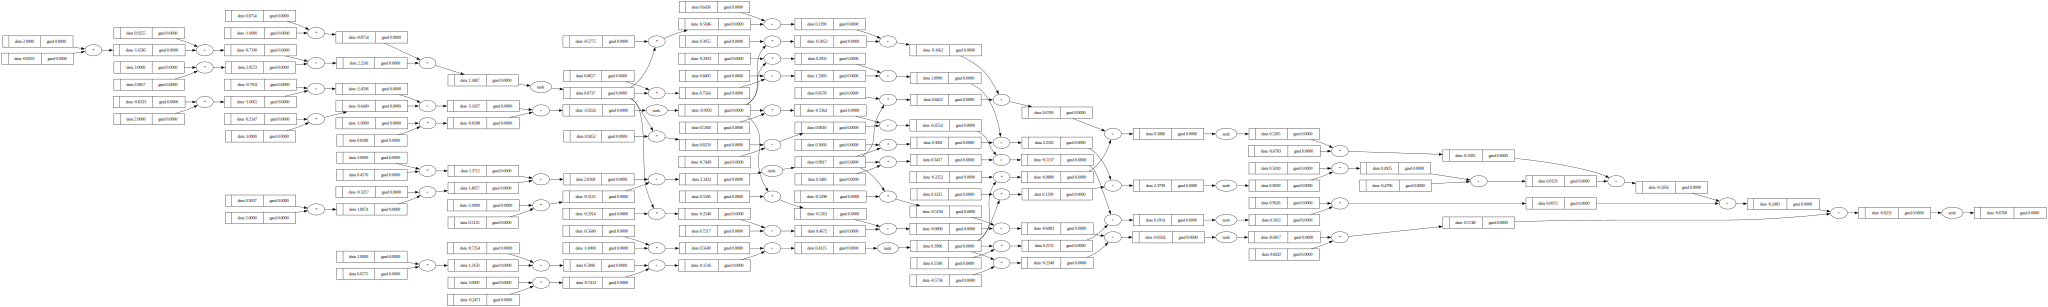

In [26]:
draw_dot(n(x))

In [37]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
# that means for the input `[2.0, 3.0, -1.0]` the desired output should be `1.0`
ypred = [n(x) for x in xs]
ypred # this is our current ypred, and we want to modify that using DNN training. 

[Value(data=-0.8153900511883209),
 Value(data=0.8323210849315323),
 Value(data=-0.5663702247354687),
 Value(data=-0.7086738064790746)]

For our predicted values to be close to the predicted values, we need to change the parameters.  
- But first we need to calculate how bad out model is performing. And that number is defined by `loss`. 
- Here we would be using the MSE(Mean Squared Error)

In [38]:
# loss 
[(yout -ygt)**2 for ygt, yout in zip(ys, ypred)] # the ypred is the output from the model

[Value(data=3.295641037953535),
 Value(data=3.3574005582846675),
 Value(data=0.1880347819959679),
 Value(data=2.9195661769476904)]

In [39]:
loss = sum((yout -ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=9.76064255518186)

In [40]:
loss.backward()

In [41]:
n.layers[0].neurons[0].w[0].grad

-0.4291501400055704

In [42]:
n.layers[0].neurons[0].w[0].data

0.11388986025313819

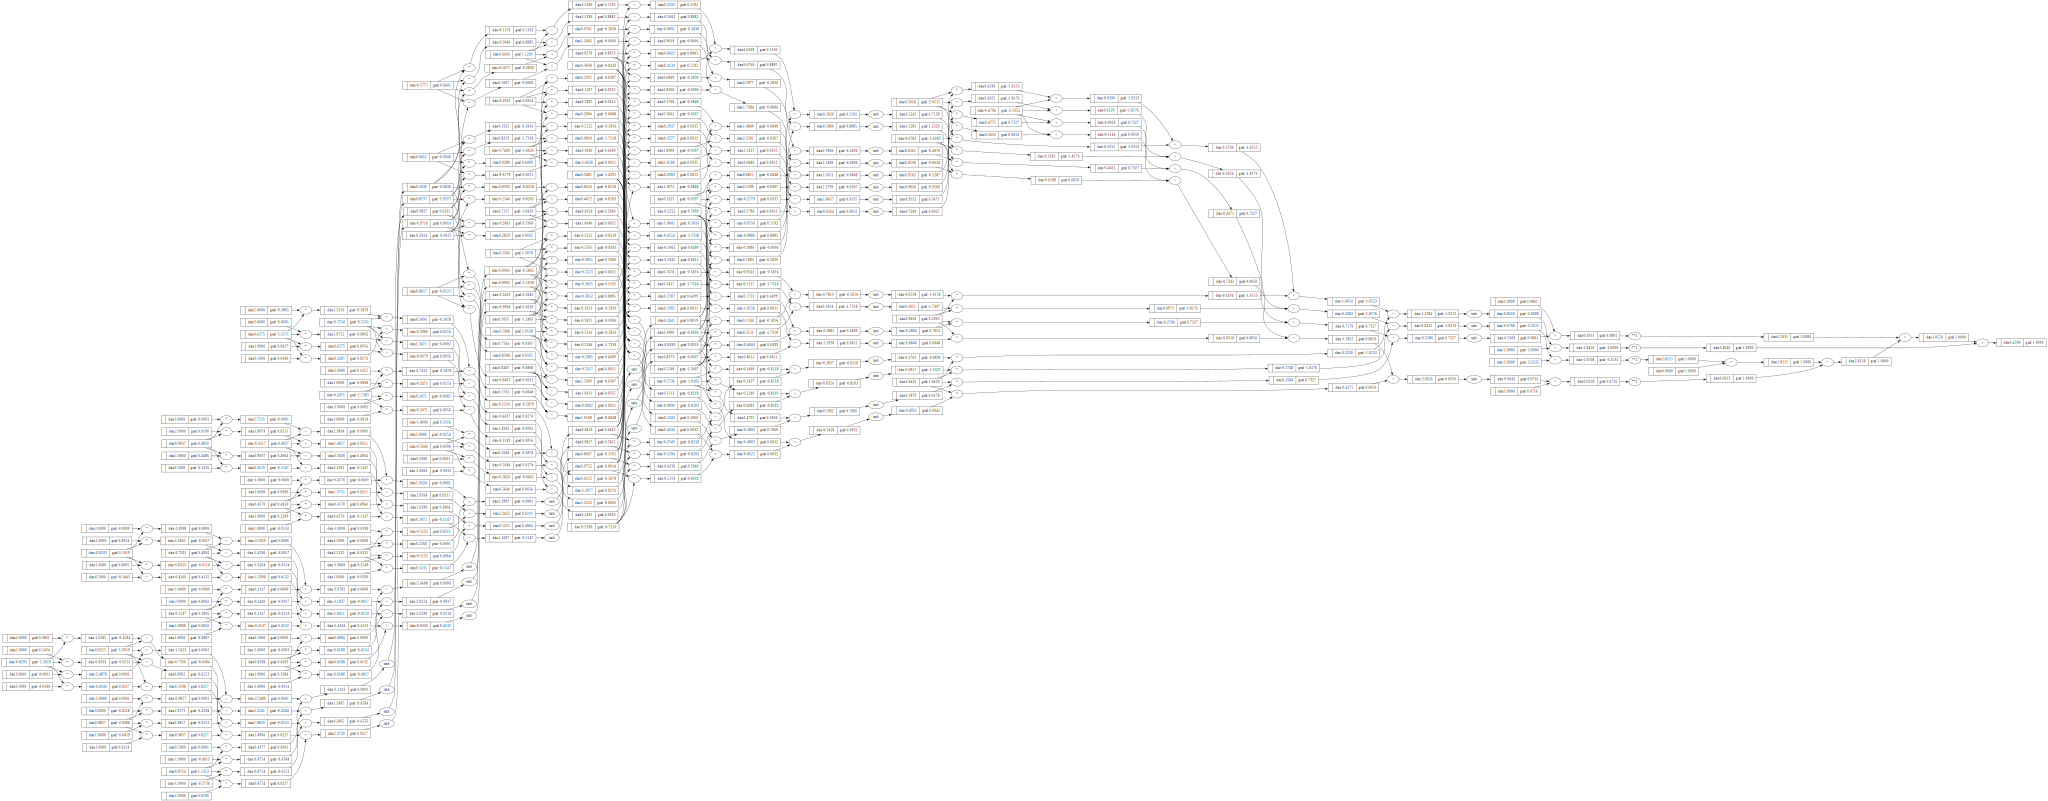

In [32]:
draw_dot(loss)

Even though we have gradients for the 1st layer/input layer, where the value are `xs` itself, there we would not be modifying `xs` because of the gradients.  

Also adding the `parameters()` method to all the classes for gradient descent

In [36]:
import random

class Neuron:
  
  # here `nin` is the no. of inputs to the cell body
  def __init__(self, nin):
    # it creates a random weight between -1 and 1 for every input. i.e. w_i for every x_i
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1)) # a single bias. 
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # y = m1x1 +m2x2 + .... + b
    out = act.tanh()
    return out

  # we will need that for gradient descent. it stores all the values and their gradients. 
  # need better understanding
  def parameters(self):
    return self.w + [self.b]
  
# A layer is just a list of Neurons
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs # extracting just the element for output, if that's the last neuron.
    # or if that is te last layer used of for the output. 
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
  
class MLP:
  
  def __init__(self, nin, nouts):
    # sz is the size of all the layers in the MLP (no. of neurons in each layer)
    sz = [nin] + nouts # that concats the list and creates `sz = [3, 4, 4, 1]`. explanation below. 
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) 
    return x

  # for gradient descent
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]
  

  
x = [2.0, 3.0, -1.0] # dimension of input 
"""
n = Neuron(3) # here 3 is the `nin`, or no. of inputs. That means the dimension. 
# doesn't matter the size of `x`, the input size of the Neuron is all that matters. If its smaller than the 
# length of x, then it will trim; as we have used the zip() function.  
n = Layer(3, 4) # Here 4, or `nout` is the no. of neurons in a single layer. And each neuron will have 3 `nin`.
"""
n = MLP(3, [4, 4, 1]) # here 1st 3 determines the input dimension, 
# followed by the two 4s which are the middle layers
# finally 1 output layer. this represents the MLP in fig1. above. 
n(x) 

Value(data=-0.8153900511883209)

In [43]:
# Implementing gradient descent 
for p in n.parameters():
    p.data += -0.01 * p.grad

In [44]:
ypred

[Value(data=-0.8153900511883209),
 Value(data=0.8323210849315323),
 Value(data=-0.5663702247354687),
 Value(data=-0.7086738064790746)]

In [54]:
# Next iteration
ypred = [n(x) for x in xs]
loss = sum((yout -ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.0938148498213363)

In [55]:
loss.backward()
# ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [56]:
# Implementing gradient descent 
for p in n.parameters():
    p.data += -0.1 * p.grad

ypred

[Value(data=0.9992108886961433),
 Value(data=-0.7231904262590242),
 Value(data=-0.8689062267306449),
 Value(data=0.997739553135193)]

In a few iterations the loss is decreasing. Also the `0.1` here is teh learning rate

In [ ]:
n.parameters() # this is on what the loss is calculated and adjusted. 

[Value(data=-0.3673755816308223),
 Value(data=0.1314392339538137),
 Value(data=-0.9431446135199255),
 Value(data=-1.0753330827630667),
 Value(data=0.6163310113571294),
 Value(data=-0.2865365543455912),
 Value(data=-1.4825698634298106),
 Value(data=-0.5525243529169765),
 Value(data=1.5049709249115977),
 Value(data=-0.18943019567761082),
 Value(data=-0.2639705906187334),
 Value(data=0.3031331860065456),
 Value(data=1.8180540198023505),
 Value(data=0.17409111738974298),
 Value(data=-1.7143016115547685),
 Value(data=0.18470940550205966),
 Value(data=-0.48741785438392843),
 Value(data=-1.2531178183604341),
 Value(data=-0.3786164532817258),
 Value(data=-0.8748397708327427),
 Value(data=-0.27679429441927167),
 Value(data=1.4361942945139168),
 Value(data=0.7384957451598734),
 Value(data=-0.9288765878362435),
 Value(data=0.6221065076630327),
 Value(data=-0.20627065777643855),
 Value(data=-0.61795173755981),
 Value(data=-0.2935549594108172),
 Value(data=1.4230682481010235),
 Value(data=-0.350828

Merging all the code fragments into a single loop

In [59]:
# Also reinitializing the data 
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # this is important, as for the backward pass without this reset, 
    # the previous values are getting accumulated due to the `+=` 
    # Reference would be in the `Value` class we initialized the grad with 0.0 due to the same reason. 
  loss.backward()
  
  # update
  # using gradient descent
  for p in n.parameters():
    p.data += -0.05 * p.grad
  
  print(k, loss.data)
  

0 0.0019313927703713501
1 0.0019164651579307828
2 0.0019017626581331797
3 0.0018872802475142397
4 0.0018730130504771515
5 0.001858956333903388
6 0.0018451055019970389
7 0.0018314560913511655
8 0.001818003766225027
9 0.0018047443140216755
10 0.0017916736409562101
11 0.0017787877679052585
12 0.0017660828264290734
13 0.001753555054957742
14 0.0017412007951339006
15 0.0017290164883042047
16 0.0017169986721529429
17 0.001705143977470825
18 0.001693449125052718
19 0.0016819109227185116


In [61]:
ypred

[Value(data=0.999957525214247),
 Value(data=-0.9965555616966699),
 Value(data=-0.9591342602190036),
 Value(data=0.9998095386193248)]